In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.cluster import KMeans
df = pd.read_csv('customer_segmentation_data.csv')
df.head()

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2


In [4]:
##EDA - Datanin sade analizi. Ilkin melumatlar. 3-4 plot cixarin
df.drop(columns=['Geographic Information'], inplace=True)

#Data Preprocessing. Missing value, inconsistent

In [5]:
df

,Customer ID,Age,Gender,Marital Status,Education Level,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,Female,Married,Associate Degree,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53498,44809,35,Female,Divorced,Associate Degree,Salesperson,120850,policy3,01-01-2019,Mobile App,policy1,586401,4404,Family,In-Person Meeting,Phone,Afternoon,German,Segment5
53499,65485,61,Male,Single,Doctorate,Entrepreneur,122309,policy5,5/18/2021,Mobile App,policy4,637733,1285,Group,Text,Mail,Afternoon,German,Segment1
53500,26213,25,Male,Divorced,Doctorate,Teacher,49258,policy2,11/27/2018,In-Person,policy1,631057,4407,Individual,Text,Text,Weekends,French,Segment4
53501,63136,42,Male,Married,Doctorate,Artist,66301,policy4,06-04-2021,In-Person,policy1,730385,4482,Business,Mail,Phone,Morning,French,Segment5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Customer ID                         53503 non-null  int64 
 1   Age                                 53503 non-null  int64 
 2   Gender                              53503 non-null  object
 3   Marital Status                      53503 non-null  object
 4   Education Level                     53503 non-null  object
 5   Occupation                          53503 non-null  object
 6   Income Level                        53503 non-null  int64 
 7   Behavioral Data                     53503 non-null  object
 8   Purchase History                    53503 non-null  object
 9   Interactions with Customer Service  53503 non-null  object
 10  Insurance Products Owned            53503 non-null  object
 11  Coverage Amount                     53503 non-null  in

In [7]:
df.describe()

,Customer ID,Age,Income Level,Coverage Amount,Premium Amount
count,53503.000000,53503.000000,53503.000000,53503.000000,53503.000000
mean,52265.204998,44.140945,82768.324318,492580.789638,3023.702447
std,28165.000067,15.079486,36651.075670,268405.505571,1285.834295
min,1.000000,18.000000,20001.000000,50001.000000,500.000000
25%,28950.500000,32.000000,51568.500000,249613.500000,1817.000000
50%,55858.000000,43.000000,80719.000000,477261.000000,3194.000000
75%,76096.000000,57.000000,115973.500000,739124.000000,4311.500000
max,100000.000000,70.000000,149999.000000,1000000.000000,5000.000000


In [11]:
df.drop(columns=['Purchase History'], inplace=True)
#df.drop(columns=['Customer ID'], inplace=True)

In [9]:
df=df.drop(columns=['Segmentation Group'])

In [10]:
df = df.sample(n=5000)
#df=df.drop(columns=['Segmentation Group'])
df

,Age,Gender,Marital Status,Education Level,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language
48847,55,Male,Widowed,Doctorate,Teacher,46630,policy5,03-04-2023,Mobile App,policy1,584980,1802,Individual,Phone,Email,Afternoon,French
31934,54,Female,Single,Associate Degree,Engineer,97346,policy4,1/24/2019,Mobile App,policy5,193520,4150,Group,Mail,Mail,Evening,French
12724,63,Male,Divorced,Master's Degree,Teacher,115563,policy1,11-06-2023,In-Person,policy3,920386,4294,Group,In-Person Meeting,Text,Morning,French
16978,52,Male,Widowed,High School Diploma,Salesperson,94722,policy2,2/18/2021,Chat,policy2,206772,3657,Individual,Mail,Text,Anytime,English
17472,68,Male,Married,Doctorate,Doctor,88453,policy3,03-02-2022,Chat,policy1,770045,4257,Family,Phone,In-Person Meeting,Evening,Spanish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19297,47,Female,Divorced,High School Diploma,Doctor,119430,policy1,12-10-2020,Mobile App,policy2,693721,4534,Family,In-Person Meeting,Text,Weekends,Spanish
10215,45,Male,Widowed,Associate Degree,Manager,85276,policy2,10/25/2019,In-Person,policy1,281843,4269,Group,Phone,In-Person Meeting,Evening,Spanish
28371,45,Male,Widowed,Associate Degree,Nurse,61581,policy3,1/17/2018,Chat,policy5,280190,2837,Group,Text,Phone,Weekends,Mandarin
19996,50,Female,Married,Doctorate,Manager,26277,policy2,6/26/2018,Phone,policy4,173462,797,Family,Text,Text,Evening,English


In [325]:
df.duplicated().sum() ##dublicat yoxdur

np.int64(0)

In [326]:
df.isnull().sum() ##missing

Customer ID                           0
Age                                   0
Gender                                0
Marital Status                        0
Education Level                       0
Occupation                            0
Income Level                          0
Behavioral Data                       0
Interactions with Customer Service    0
Insurance Products Owned              0
Coverage Amount                       0
Premium Amount                        0
Policy Type                           0
Customer Preferences                  0
Preferred Communication Channel       0
Preferred Contact Time                0
Preferred Language                    0
dtype: int64

In [296]:
df.columns##sutun adi

Index(['Age', 'Gender', 'Marital Status', 'Education Level', 'Occupation',
       'Income Level', 'Behavioral Data', 'Interactions with Customer Service',
       'Insurance Products Owned', 'Coverage Amount', 'Premium Amount',
       'Policy Type', 'Customer Preferences',
       'Preferred Communication Channel', 'Preferred Contact Time',
       'Preferred Language'],
      dtype='object')

In [187]:
df["Marital Status"].value_counts() ##Widowed heyat yoldasi olub Separated-remsi omayan ayrilma

Marital Status
Divorced     1264
Married      1204
Widowed       861
Single        856
Separated     815
Name: count, dtype: int64

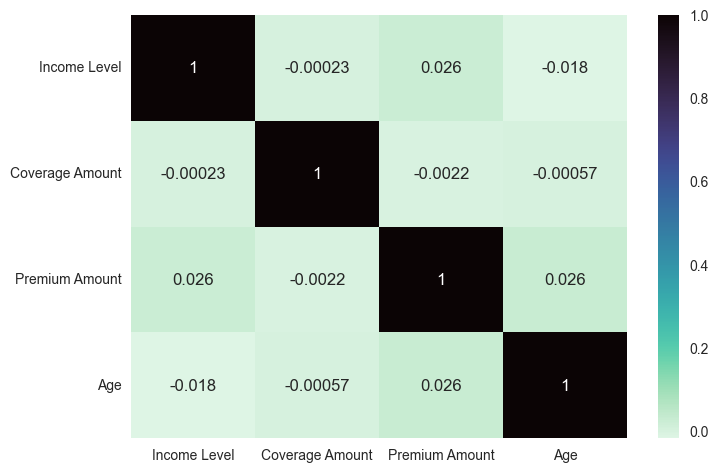

In [188]:
corr = df[['Income Level','Coverage Amount','Premium Amount','Age']].corr()
sns.heatmap(corr, annot=True, cmap="mako_r")
plt.show()##eleaqe yoxdur hec

<Axes: xlabel='Policy Type', ylabel='Coverage Amount'>

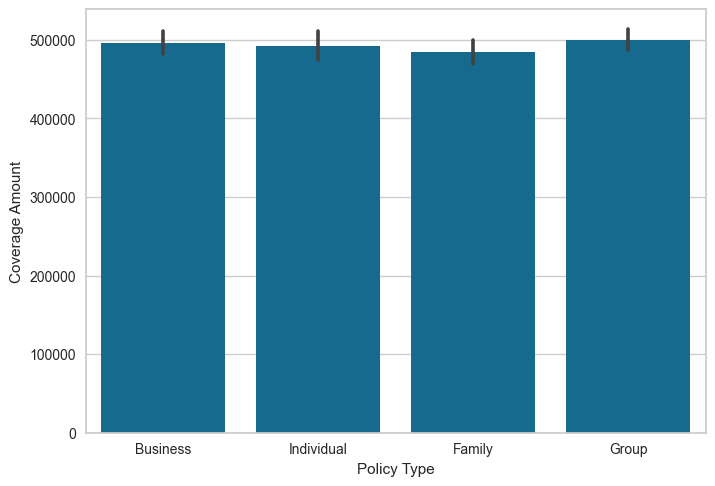

In [189]:
##covarage amountu plocy type  olmasina gore check ede bilerem
df.groupby("Policy Type")["Coverage Amount"].mean(numeric_only=True)
## burdan gorunur ki groupda groupda amount en coxdur  familyde  en azdir
sns.barplot(data = df , x ="Policy Type", y = "Coverage Amount")


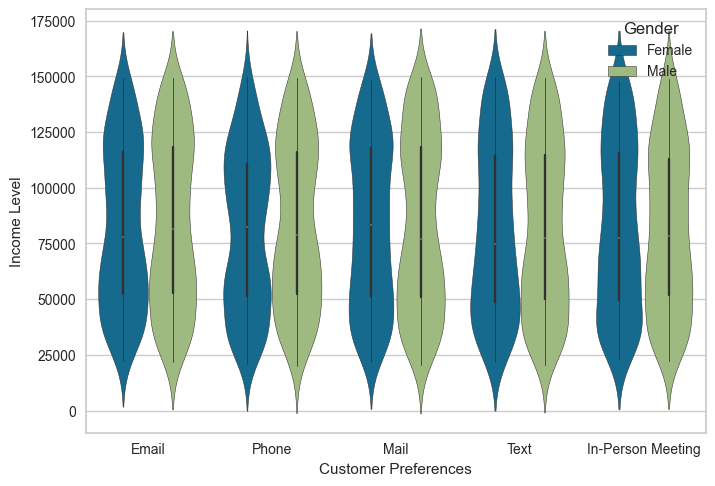

In [190]:
sns.violinplot(data=df, x="Customer Preferences", y="Income Level", hue="Gender")
plt.show() 
## burda ele de ferq yoxdur amma (500 sample veren ucun idi--maleler famelae nisbtene income level bir tik cox oldugunu gore bilerik(ve nisbeten in persone metig sekilde 
#musteri ile elaqe saxlayanlarin income leveli bir tik digerlerinden coxdur)

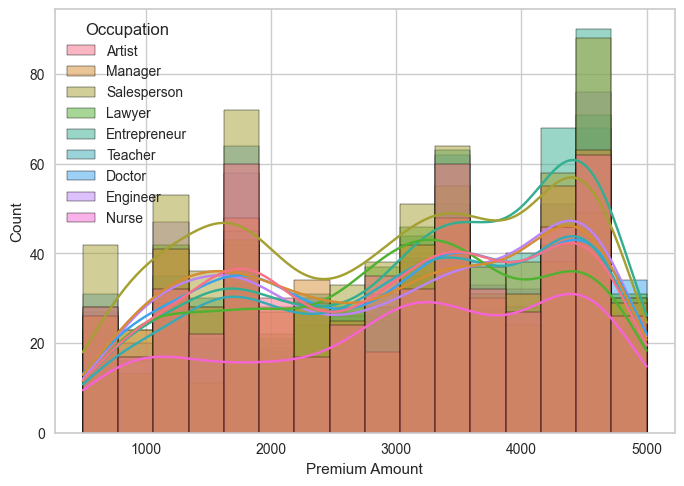

In [191]:
sns.histplot(data = df , x = "Premium Amount", hue = "Occupation", kde = True)

plt.show()


##occupation ucun premium attandance paylanmasi burdan goruruk ki salespersonlarin premium attandence daha yuksekdir

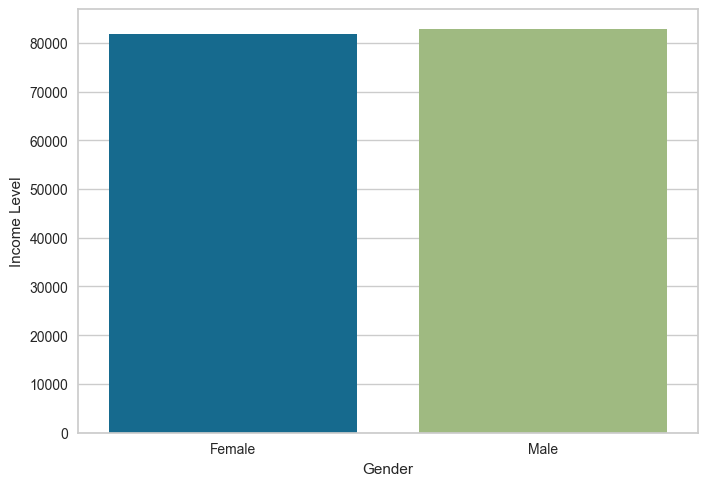

In [192]:
sns.barplot(data = df , x ="Gender", y = "Income Level", hue = "Gender", errorbar=None)
plt.show()
##malelerin income leveli daha yuksekdir azaciq 

<Axes: xlabel='Income Level', ylabel='Coverage Amount'>

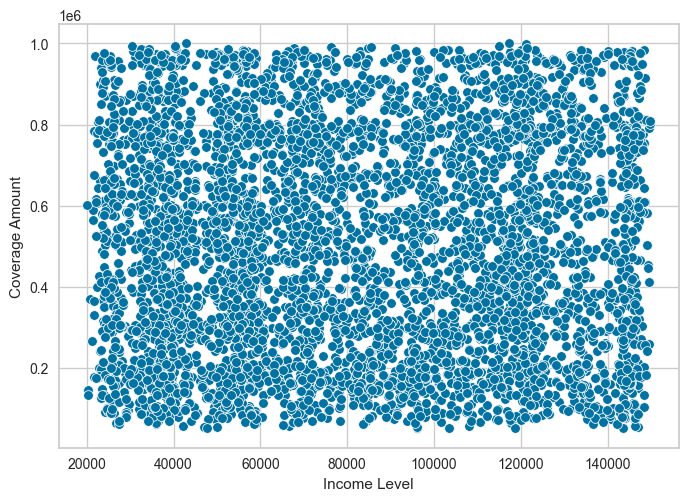

In [193]:
#3. Kmeans (K-nin secilmesi)
from sklearn.cluster import KMeans
sns.scatterplot(data = df, x = "Income Level", y="Coverage Amount")

In [12]:
X = df[["Income Level", "Premium Amount", "Coverage Amount", "Age"]]


In [195]:
wcss = []
for i in range(1,10):
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

In [196]:
wcss# classteer syaini tapamq ucun ist olunur

[363429317815889.06,
 92366435257087.22,
 43974043683233.29,
 28752606560320.22,
 20334096794939.543,
 15915750301509.062,
 13989687777634.44,
 13004325590057.145,
 10990659454872.291]

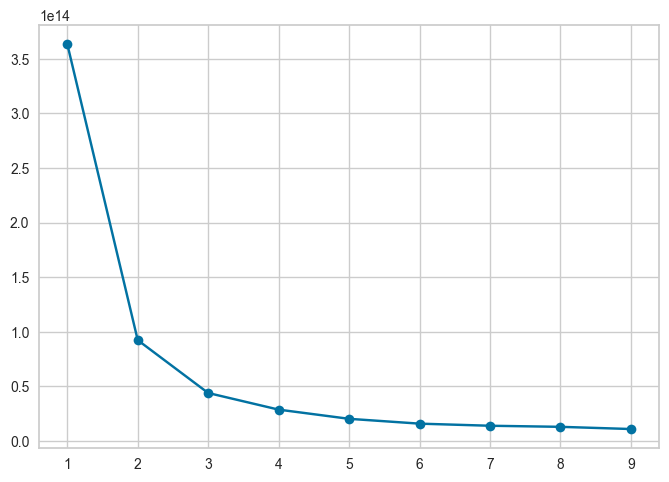

In [197]:
plt.plot(np.arange(1,10), wcss,marker = "o") ##burda eslinde  3 kimi gorunur mence(cunki orda qirilir amma biz 5 demisdik evvelden

In [ ]:

from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
scaler = StandardScaler()
X = scaler.fit_transform(X) ##scaling edek age e gore 

In [198]:
kmeans = KMeans(n_clusters = 2)
kmeans.fit(X)
kmeans.labels_

array([0, 0, 1, ..., 0, 0, 1], shape=(5000,), dtype=int32)

In [199]:
from sklearn.metrics import silhouette_score
ss = []
for i in range(2,10):
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(X)
    s = silhouette_score(X , kmeans.labels_)
    ss.append(s)


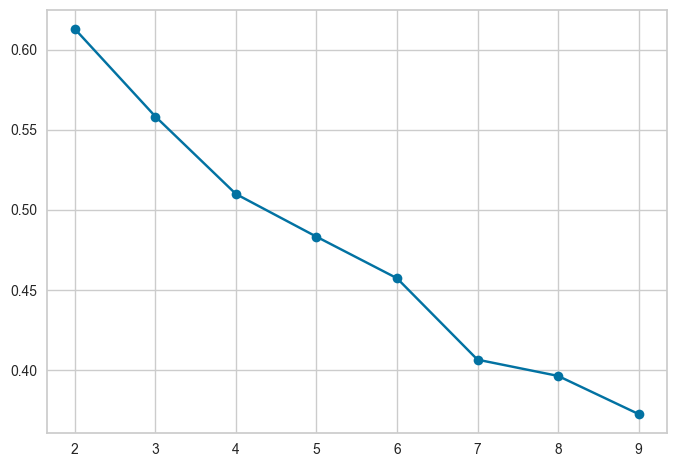

In [200]:
plt.plot(np.arange(2,10), ss,marker = "o") ## en yuksek ikide alir dmelei cluster count ikidir

In [201]:
kmeans = KMeans(n_clusters = 2)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [202]:
kmeans.labels_

array([1, 1, 0, ..., 1, 1, 0], shape=(5000,), dtype=int32)

<Axes: xlabel='Income Level', ylabel='Coverage Amount'>

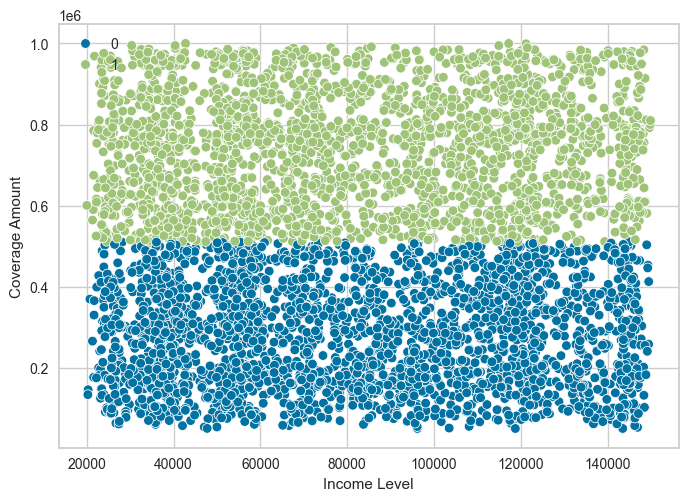

In [203]:
sns.scatterplot(data = df, x = "Income Level", y="Coverage Amount",hue=kmeans.labels_)

In [204]:
kmeans = KMeans(n_clusters = 5)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


<Axes: xlabel='Income Level', ylabel='Coverage Amount'>

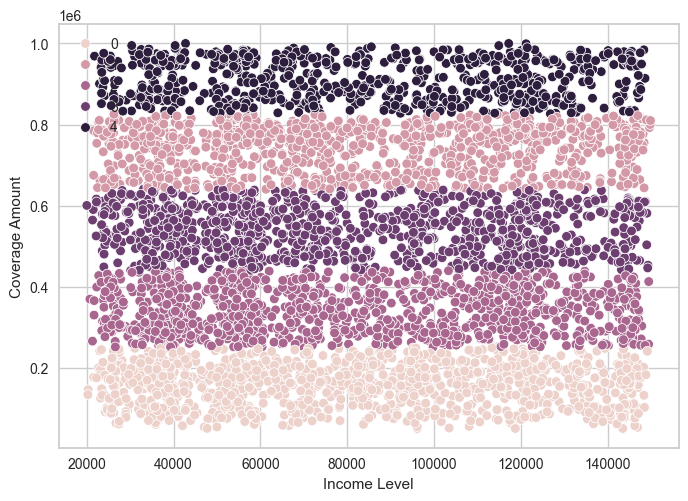

In [205]:
sns.scatterplot(data = X, x = "Income Level", y="Coverage Amount",hue=kmeans.labels_)

In [206]:

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.cluster import KMeans

,estimator,KMeans(n_clusters=3)
,ax,<Axes: >
,colors,None
,is_fitted,'auto'
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None


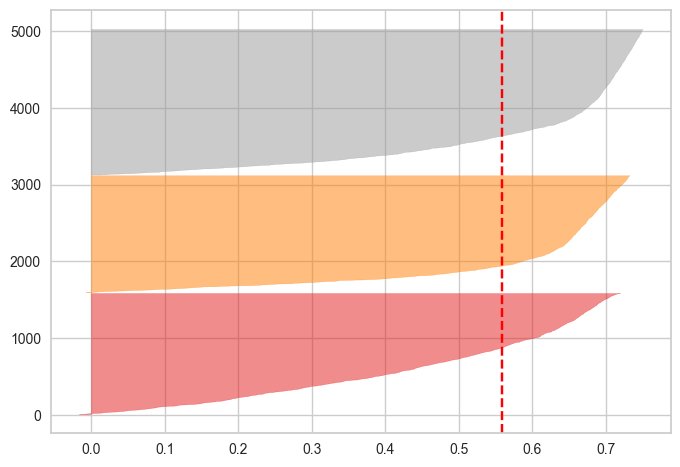

In [207]:
model = KMeans(n_clusters =3,)
sil = SilhouetteVisualizer(model,force_model=True)
sil.fit(X)## #sluetscore ne qeder cox olsa o qeder yaxsidir

In [165]:
#5. Agglomerative clustering (qiymetlendirme)
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
##bunu sonra edecem

In [221]:
#KPrototip usulu


import pandas as pd
from kmodes.kprototypes import KPrototypes



In [225]:
import pandas as pd
from kmodes.kprototypes import KPrototypes

Y = df[["Income Level","Premium Amount","Coverage Amount","Age","Gender","Marital Status","Education Level"]].copy()

# categorical sütunları string et
for col in ["Gender", "Marital Status", "Education Level"]:Y[col] = Y[col].astype(str)

# numpy array
Y_matrix = Y.values



kproto = KPrototypes(n_clusters=2, init='Cao', verbose=2)

clusters = kproto.fit_predict(Y_matrix, categorical=[4,5,6])

df['cluster'] = clusters


Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 514, ncost: 93575322664656.94
Run: 1, iteration: 2/100, moves: 166, ncost: 92439110287014.61
Run: 1, iteration: 3/100, moves: 40, ncost: 92371313010389.45
Run: 1, iteration: 4/100, moves: 16, ncost: 92362102916996.52
Run: 1, iteration: 5/100, moves: 12, ncost: 92356547622363.6
Run: 1, iteration: 6/100, moves: 5, ncost: 92355763501351.72
Run: 1, iteration: 7/100, moves: 0, ncost: 92355763501351.72
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 1296, ncost: 97987006291347.47
Run: 2, iteration: 2/100, moves: 354, ncost: 93111121071900.11
Run: 2, iteration: 3/100, moves: 131, ncost: 92425145152871.06
Run: 2, iteration: 4/100, moves: 41, ncost: 92361715296335.47
Run: 2, iteration: 5/100, moves: 8, ncost: 92359678226436.81
Run: 2, iteration:

In [222]:
df.columns

Index(['Age', 'Gender', 'Marital Status', 'Education Level', 'Occupation',
       'Income Level', 'Behavioral Data', 'Interactions with Customer Service',
       'Insurance Products Owned', 'Coverage Amount', 'Premium Amount',
       'Policy Type', 'Customer Preferences',
       'Preferred Communication Channel', 'Preferred Contact Time',
       'Preferred Language'],
      dtype='object')

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 52826 to 50958
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 5000 non-null   int64 
 1   Gender                              5000 non-null   object
 2   Marital Status                      5000 non-null   object
 3   Education Level                     5000 non-null   object
 4   Occupation                          5000 non-null   object
 5   Income Level                        5000 non-null   int64 
 6   Behavioral Data                     5000 non-null   object
 7   Interactions with Customer Service  5000 non-null   object
 8   Insurance Products Owned            5000 non-null   object
 9   Coverage Amount                     5000 non-null   int64 
 10  Premium Amount                      5000 non-null   int64 
 11  Policy Type                         5000 non-null   obje

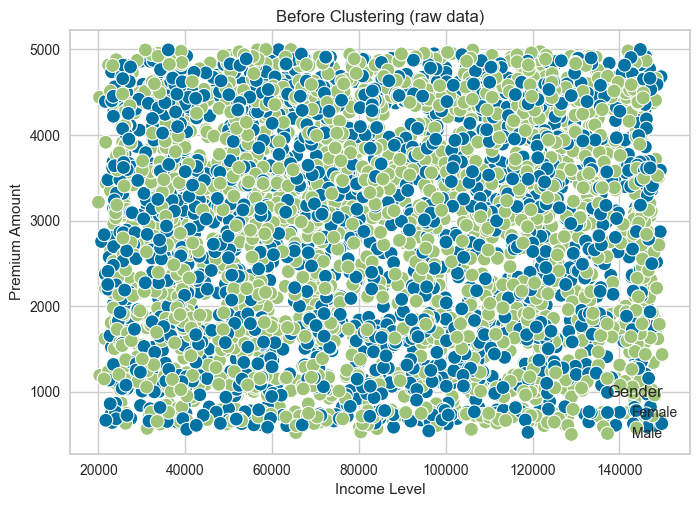

In [228]:

sns.scatterplot(data=df, x='Income Level', y='Premium Amount', hue='Gender', s=100)
plt.title("Before Clustering (raw data)")
plt.show()
##evvel

In [231]:
kmeans.cluster_centers_

array([[8.31447574e+04, 2.98364356e+03, 1.60078040e+05, 4.39892739e+01],
       [8.29168431e+04, 2.97903385e+03, 7.40687689e+05, 4.34533333e+01],
       [8.18782047e+04, 2.94855636e+03, 3.40443382e+05, 4.37511271e+01],
       [8.04912707e+04, 3.05473130e+03, 5.39674962e+05, 4.43100394e+01],
       [8.31073532e+04, 2.93666424e+03, 9.12233622e+05, 4.42485465e+01]])

In [233]:
df.groupby('cluster')[['Income Level', 'Premium Amount', 'Coverage Amount', 'Age']].mean()
##mselen bunu cixara bilerik ki her clusterde income level premium amount ve s meand ne qederdir
##bu arada age-ye gore vvel scaling elemli idim dusune bilersiz onu edende dondu deye etmedimm

,Income Level,Premium Amount,Coverage Amount,Age
cluster,,,,
0,81644.094948,2990.187718,746615.018728,43.92770
1,82810.815459,2976.791420,279376.924186,43.93713


In [235]:
#5. Agglomerative clustering (qiymetlendirme)
from scipy.cluster.hierarchy import dendrogram

In [236]:
def plot_dendrogram(model, **kwargs):
 

 
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)


    dendrogram(linkage_matrix, **kwargs)

In [237]:
agg = AgglomerativeClustering(linkage = "average", distance_threshold=0, n_clusters=None)
agg.fit(X)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'average'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


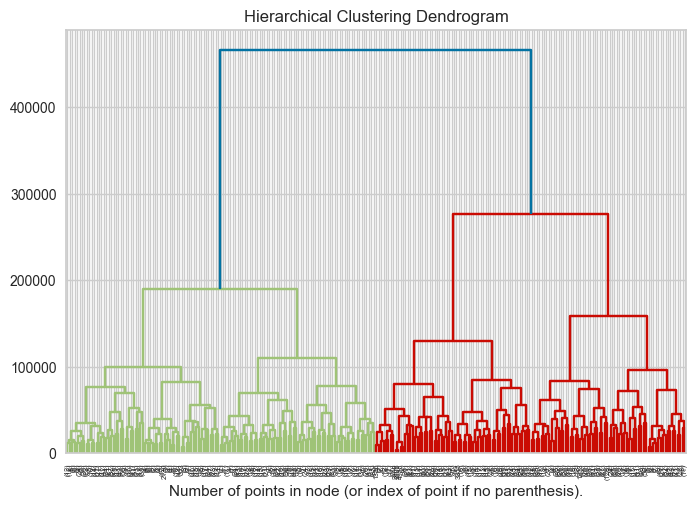

In [238]:
plt.title("Hierarchical Clustering Dendrogram")

plot_dendrogram(agg, truncate_mode="level", p=7)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show() ##bundan iki dene sluste cixara bilerik

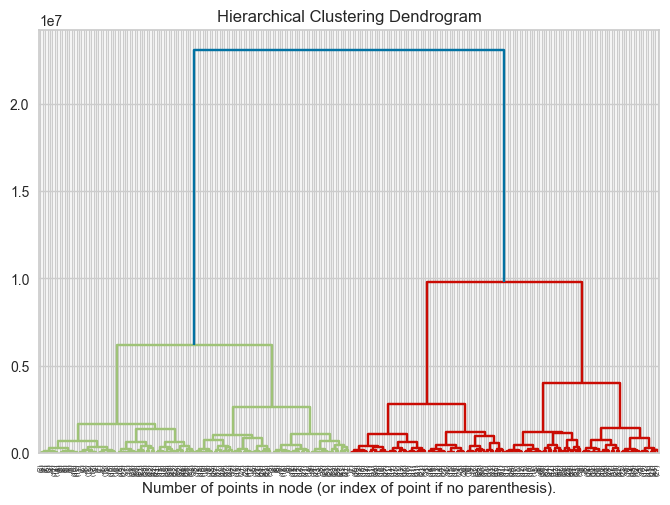

In [239]:
agg = AgglomerativeClustering(linkage = "ward", distance_threshold=0, n_clusters=None)
agg.fit(X)
plt.title("Hierarchical Clustering Dendrogram")

plot_dendrogram(agg, truncate_mode="level", p=7)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show() ##brda 0.5 den bolsek  4 dene clsuter olur

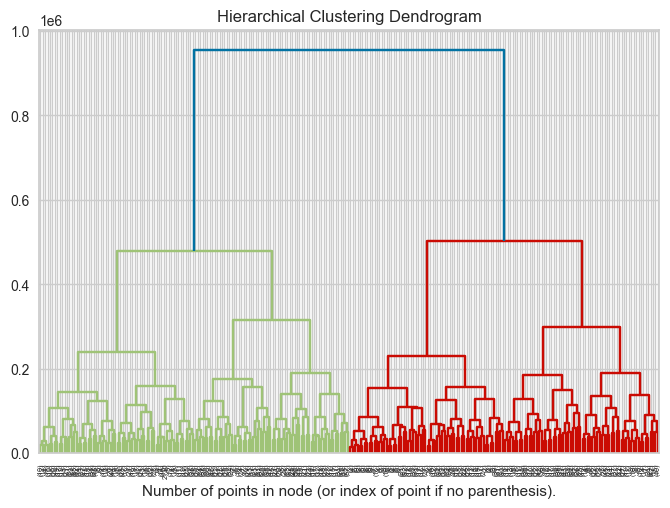

In [240]:
agg = AgglomerativeClustering(linkage = "complete", distance_threshold=0, n_clusters=None)
agg.fit(X)
plt.title("Hierarchical Clustering Dendrogram")

plot_dendrogram(agg, truncate_mode="level", p=7)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show() ##brda 0.4 den bolsek  4 dene clsuter olur

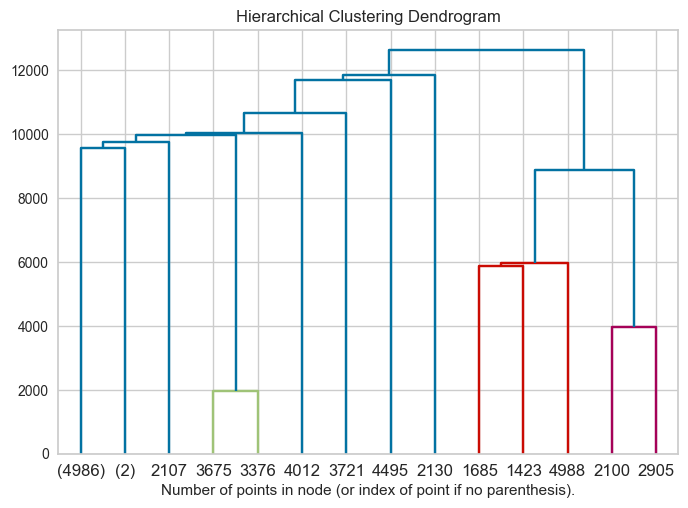

In [242]:
agg = AgglomerativeClustering(linkage = "single", distance_threshold=0, n_clusters=None)
agg.fit(X)
plt.title("Hierarchical Clustering Dendrogram")

plot_dendrogram(agg, truncate_mode="level", p=7)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show() ##en berbad budur bu ne

In [243]:
##compete yaxsdiir mence sonra da ward onlari nezere alib 4 cluster edek

In [247]:
agg = AgglomerativeClustering(n_clusters=4,linkage="ward")

agg.fit(X)
# {'ward', 'complete', 'average', 'single'}, 

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",4
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


<Axes: xlabel='Income Level', ylabel='Premium Amount'>

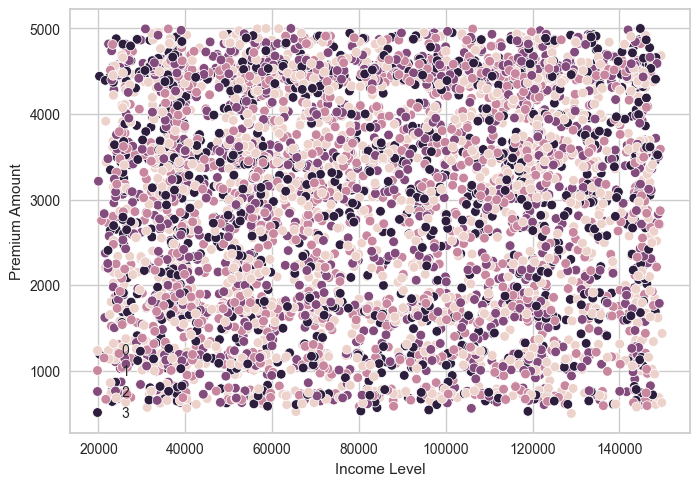

In [248]:
sns.scatterplot(data = X,  x='Income Level', y='Premium Amount', hue=agg.labels_)
##bu da duzud gorunusde bir sey oxsamadi

In [310]:
#DBSCAN ile outlierleri tap
from sklearn.cluster import DBSCAN

In [311]:
'''## briicni categoricleri encode edek
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
##okay ela qalani qalsin genderle ederem tekce''''

SyntaxError: unterminated string literal (detected at line 5) (1583511622.py, line 5)

In [312]:
df

,Age,Gender,Marital Status,Education Level,Occupation,Income Level,Behavioral Data,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language
7924,21,Male,Widowed,Bachelor's Degree,Doctor,122961,policy2,Email,policy2,414045,1340,Group,Mail,Mail,Weekends,English
40733,51,Male,Divorced,Associate Degree,Lawyer,44670,policy2,Chat,policy5,858192,4454,Group,In-Person Meeting,Mail,Weekends,French
32955,55,Female,Single,High School Diploma,Lawyer,84705,policy2,Chat,policy1,949484,3980,Business,Email,In-Person Meeting,Morning,French
48399,67,Male,Married,Doctorate,Entrepreneur,58371,policy1,Chat,policy2,827994,4863,Group,Phone,Phone,Anytime,French
53320,40,Male,Widowed,Bachelor's Degree,Salesperson,64395,policy5,In-Person,policy4,644752,3951,Group,Mail,Phone,Weekends,German
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45474,25,Female,Widowed,Master's Degree,Engineer,84629,policy2,Chat,policy3,671526,1679,Individual,Email,In-Person Meeting,Anytime,French
27323,52,Female,Married,Bachelor's Degree,Manager,102914,policy3,Mobile App,policy2,265234,4400,Individual,Phone,Phone,Evening,Spanish
27836,39,Female,Married,Bachelor's Degree,Artist,23026,policy2,Phone,policy4,291931,3518,Business,In-Person Meeting,Phone,Morning,Spanish
26992,19,Male,Single,Doctorate,Manager,63704,policy2,Chat,policy4,563819,2126,Business,Email,In-Person Meeting,Weekends,French


In [ ]:
X = df[["Income Level", "Premium Amount", "Coverage Amount", "Age"]]

In [328]:
X


,Income Level,Premium Amount,Coverage Amount,Age
52826,99967,4786,518296,58
24178,27756,4260,614661,38
21045,102166,2853,255085,40
20785,77856,2850,209199,47
39007,84169,568,122986,54
...,...,...,...,...
44173,59111,4532,193235,61
4426,73772,3315,164172,30
38965,38796,1901,545590,69
8331,42436,1666,702729,32


In [13]:
X

,Income Level,Premium Amount,Coverage Amount,Age
48847,46630,1802,584980,55
31934,97346,4150,193520,54
12724,115563,4294,920386,63
16978,94722,3657,206772,52
17472,88453,4257,770045,68
...,...,...,...,...
19297,119430,4534,693721,47
10215,85276,4269,281843,45
28371,61581,2837,280190,45
19996,26277,797,173462,50


In [16]:
X = df[["Income Level", "Premium Amount", "Coverage Amount", "Age"]]
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)
##ubrda sxaler eldim isledi yupu age mane etmesind deye Scaling edek
Xscaled

array([[-0.99533066, -0.96651601,  0.35218597,  0.72711552],
       [ 0.37710586,  0.86941319, -1.11106503,  0.66101652],
       [ 0.87007999,  0.9820085 ,  1.60591091,  1.25590758],
       ...,
       [-0.59073845, -0.15723717, -0.78709843,  0.06612545],
       [-1.54610754, -1.7523375 , -1.18604048,  0.39662049],
       [ 1.61594116,  0.12581495, -1.29501242,  1.25590758]],
      shape=(5000, 4))

In [110]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.51519, min_samples=13) 
dbscan.fit(Xscaled)
#sns.scatterplot(data=Xscaled, x ="Income Level", y="Premium Amount",hue = dbscan.labels_)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.51519
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",13
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


<Axes: xlabel='Income Level', ylabel='Premium Amount'>

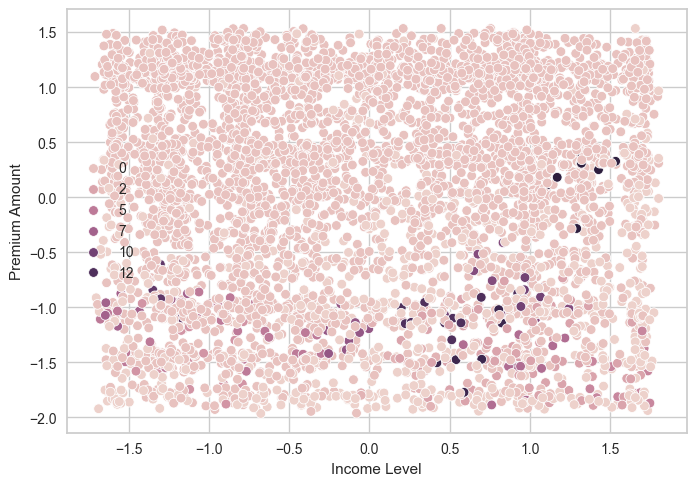

In [111]:
import pandas as pd

Xscaled_df = pd.DataFrame(Xscaled, columns=X.columns)
Xscaled_df['cluster'] = dbscan.labels_


sns.scatterplot(data=Xscaled_df, x="Income Level", y="Premium Amount", hue=dbscan.labels_)

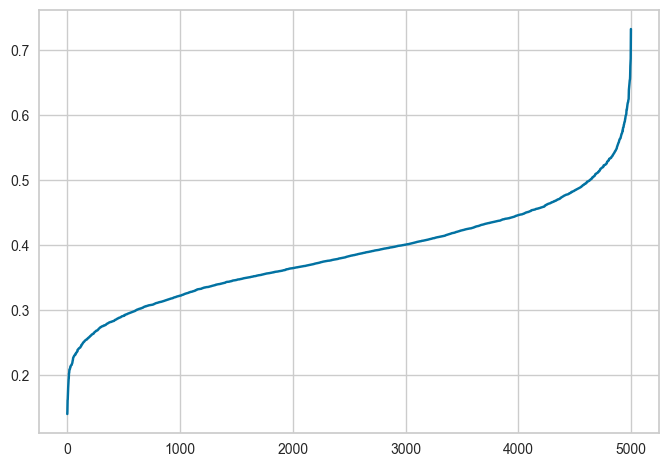

In [113]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(Xscaled)
distances, indices = neighbors_fit.kneighbors(Xscaled)

distances = np.sort(distances, axis=0)
distances = distances[:,4]
plt.plot(distances)
##emp tapdim eps  tapdiq ki 0.6 yaxsidir yuxarida ist edirem

In [114]:
##anomaly detection

In [115]:
from sklearn.ensemble import IsolationForest

iso_forest =IsolationForest(n_estimators=5) # bunla oyanay bilerik ne qeder cox olsa o qeder guvenli netice alaram
prediction = iso_forest.fit_predict(X)

<Axes: xlabel='Income Level', ylabel='Premium Amount'>

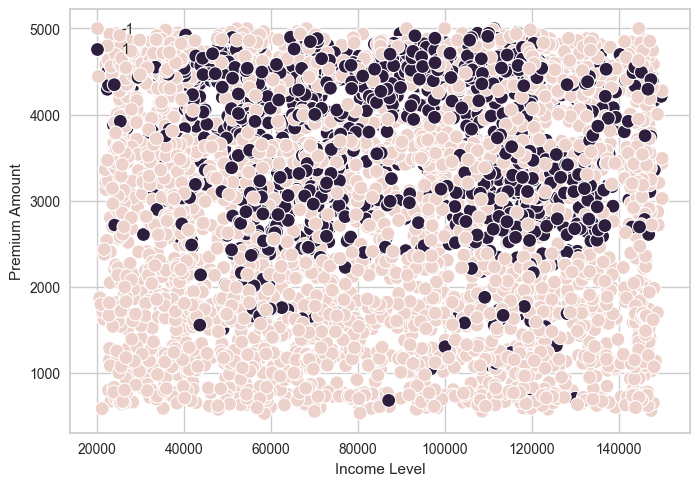

In [116]:
sns.scatterplot(data=X,  x="Income Level", y="Premium Amount", hue=prediction,  s=100)

In [127]:
from sklearn.svm import OneClassSVM
#one_svm = OneClassSVM(nu=0.1, kernel='rbf',) nu -- nu=0.05 --> model deyir ki en  cox 5% point anomaly ola biler
#nu=0.1 --> en cox 10%
one_svm = OneClassSVM(nu=0.1, kernel='rbf')
one_svm_label = one_svm.fit_predict(X) ##10% goturdum burda 

<Axes: xlabel='Income Level', ylabel='Premium Amount'>

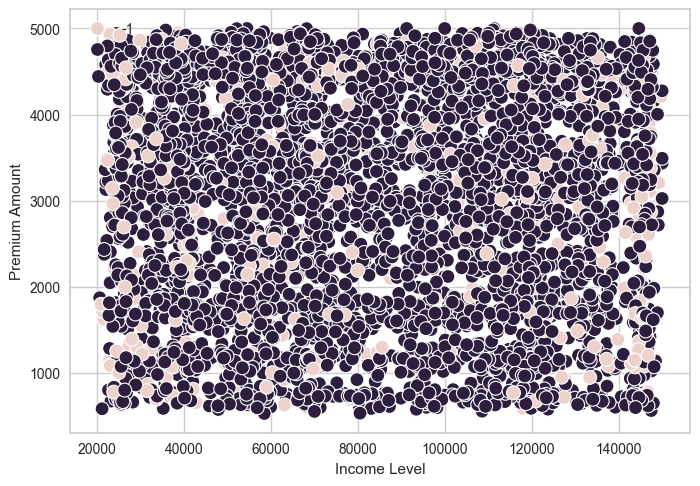

In [128]:
sns.scatterplot(data=X,  x="Income Level", y="Premium Amount", hue=one_svm_label,  s=100)

In [129]:
##9. DImensionality reduction. PCA


In [134]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [142]:
new = pca.transform(X)
new

array([[  94382.28243312,  -36361.15536715],
       [-297299.65114592,   12612.20315523],
       [ 429478.05207199,   34064.64793704],
       ...,
       [-210471.27458497,  -22766.87167324],
       [-317041.01746864,  -58545.98137335],
       [-346713.92426455,   58171.51798474]], shape=(5000, 2))

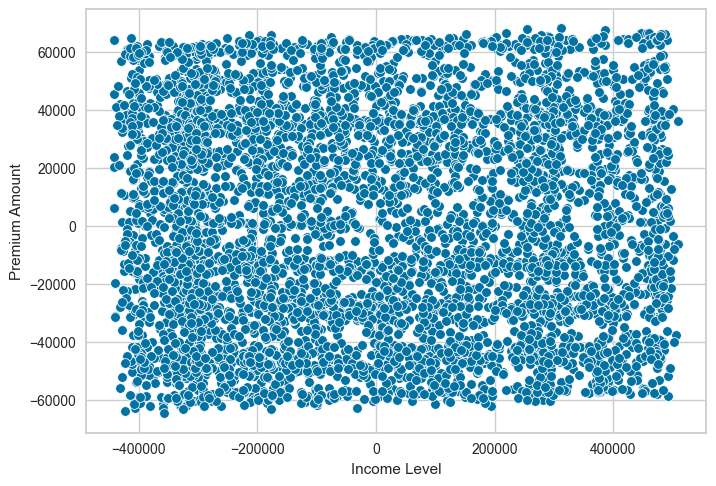

In [147]:

#new_df = pd.DataFrame(new, columns=X.columns)
import seaborn as sns
import matplotlib.pyplot as plt

new_df = pd.DataFrame(new, columns=["Income Level", "Premium Amount"])
sns.scatterplot(data=new_df, x="Income Level", y="Premium Amount")
plt.show()